<h1>Identifying likely upwind source areas for pollution events</h1>

<p>Typically run on the disaggregated output of <code>pollution_events()</code>, Air Insights can retrieve likely upwind source areas for local pollution events by querying Air Tracker with the <code>source_area()</code> function.<br>
    
Air Tracker is currently available only in certain metropolitan areas in the United States and Brazil.<br>
<small>For more information about Air Tracker methods and locations please visit <a href="https://www.edf.org/air-tracker-mapping-local-air-pollution">EDF's Air Tracker information page</a> or the <a href="https://www.edf.org/maps/gca-air-tracker/">interactive web version of Air Tracker.</small></p>

To start, we'll read in the sample black carbon data and apply the <code>pollution_events()</code> function using the code in the <i>pollution_event_notebook.ipynb</i> example. 

In [ ]:
import airinsights as air

input_data, config = air.read_aqdata_file(input_file="sample_data/oakland_2017_100x100_blackcarbon.csv",
                                          config_file="../config/example_config_output.yaml")

events, measurements = air.pollution_events(input_data, config)
measurements = input_data.merge(measurements,
                  on = [config['site_col'],
                        config['timestamp_col'],
                        config['pollutant_col']],
                  how = "left")
measurements = measurements.explode("event_ID")

Timestamp already in local timezone: America/Los_Angeles


<p>The <code>source_area()</code> function takes a DataFrame and configuration as input and returns a GeoDataFrame where each row's geometry column represents the Air Tracker footprint for that site's location at that time. A column representing the geometry in Well-Known Text (WKT) format is also included. 

For the purposes of this example, we'll filter down to one event then apply the source_area() function.</p>

In [44]:
measurements = measurements[measurements["event_ID"]=="LOC_hourly_BC_94"]
gdf = air.source_area(measurements, config)
# Sort the data by datetime to present in chronological order
gdf = gdf.sort_values("Datetime")
gdf.head()

,Datetime,Latitude,Longitude,Site,pollutant,event_ID,geometry,wkt_geometry
3,2017-07-24 23:00:00-07:00,37.81049,-122.30262,61,hourly_BC,LOC_hourly_BC_94,"POLYGON ((-122.39262 37.82727, -122.39262 37.8...","POLYGON ((-122.39262 37.827271, -122.39262 37...."
4,2017-07-25 00:00:00-07:00,37.81049,-122.30262,61,hourly_BC,LOC_hourly_BC_94,"POLYGON ((-122.36662 37.83527, -122.36662 37.8...","POLYGON ((-122.36662 37.835269, -122.36662 37...."
5,2017-07-25 01:00:00-07:00,37.81049,-122.30262,61,hourly_BC,LOC_hourly_BC_94,"POLYGON ((-122.30462 37.87125, -122.30462 37.8...","POLYGON ((-122.30462 37.871249, -122.30462 37...."
7,2017-07-25 01:00:00-07:00,37.81145,-122.30041,66,hourly_BC,LOC_hourly_BC_94,"POLYGON ((-122.30241 37.87221, -122.30241 37.8...","POLYGON ((-122.30241 37.872209, -122.30241 37...."
0,2017-07-25 02:00:00-07:00,37.80361,-122.29789,20,hourly_BC,LOC_hourly_BC_94,"POLYGON ((-122.29789 37.89235, -122.29789 37.8...","POLYGON ((-122.29789 37.892352, -122.29789 37...."


<h3>Mapping Air Tracker footprints for an event</h3>

<p>We can map Air Tracker footprints for each site and hour in an event by looping through the output GeoDataFrame, allowing us to view how winds may have shifted during the course of the event and identify possible pollution sources.</p>

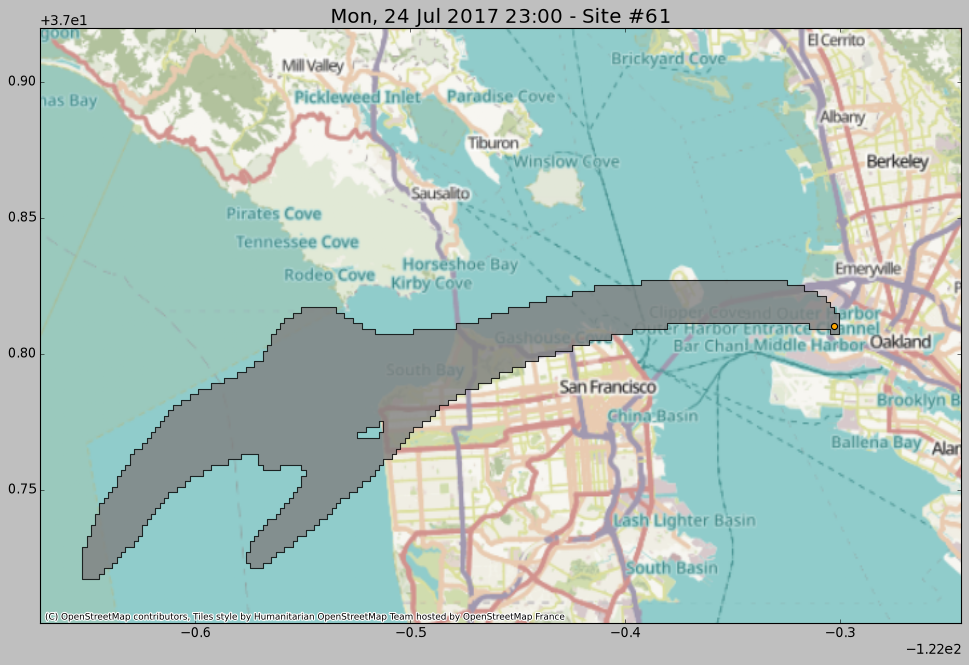

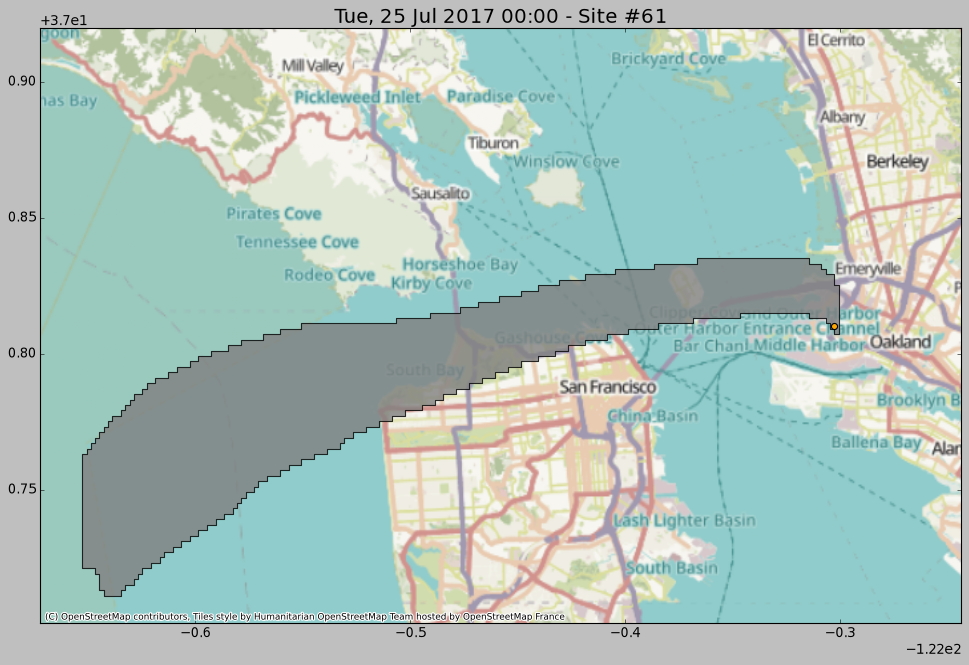

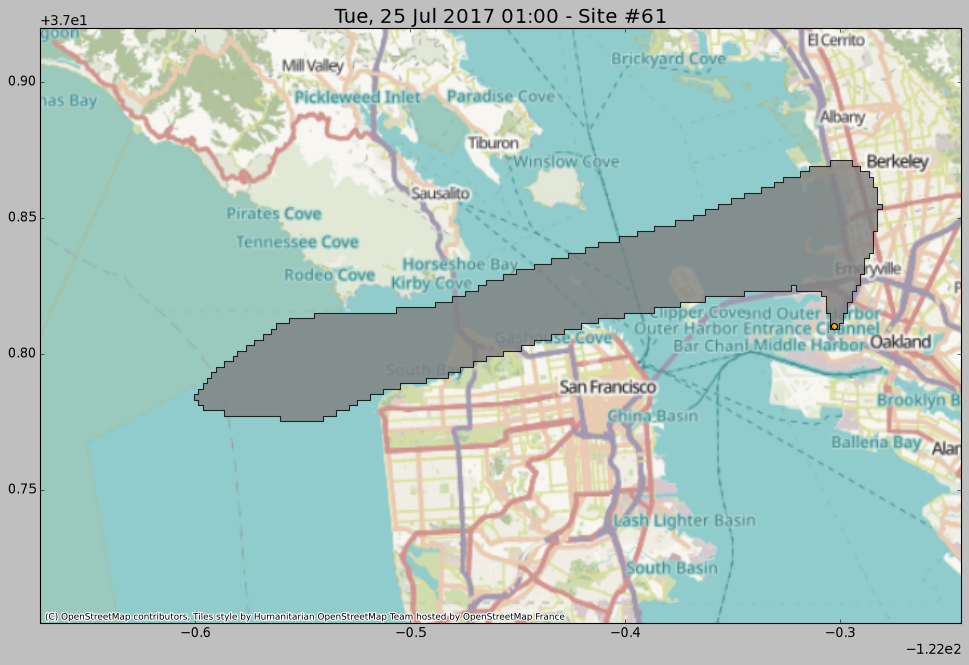

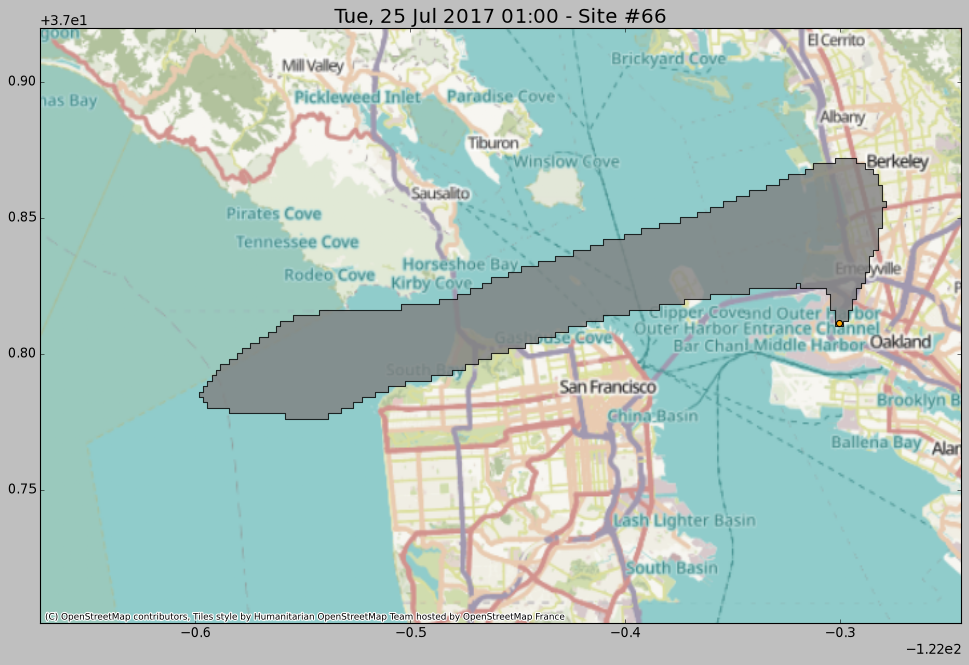

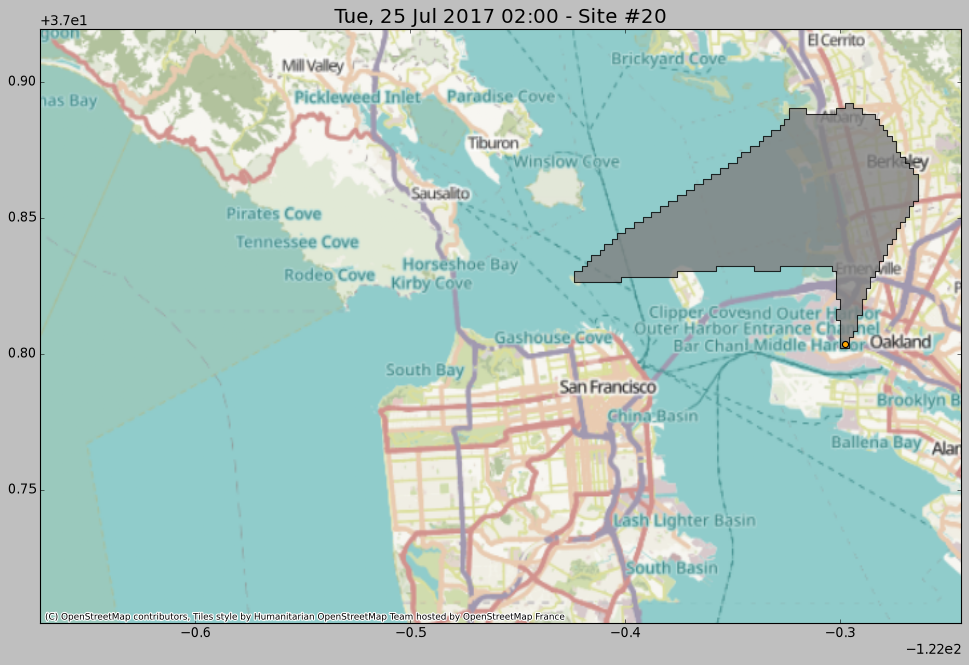

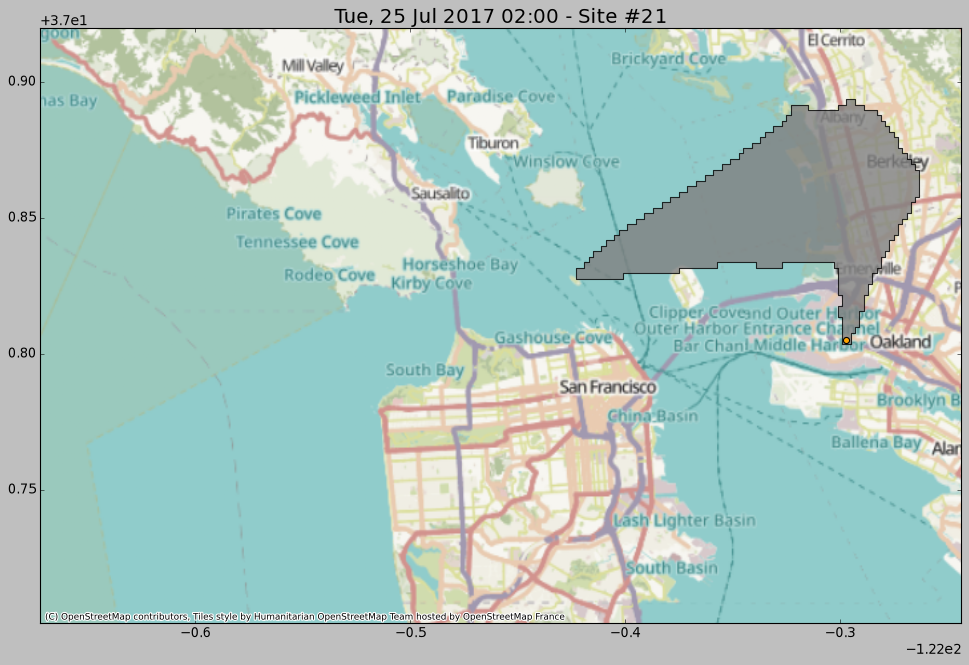

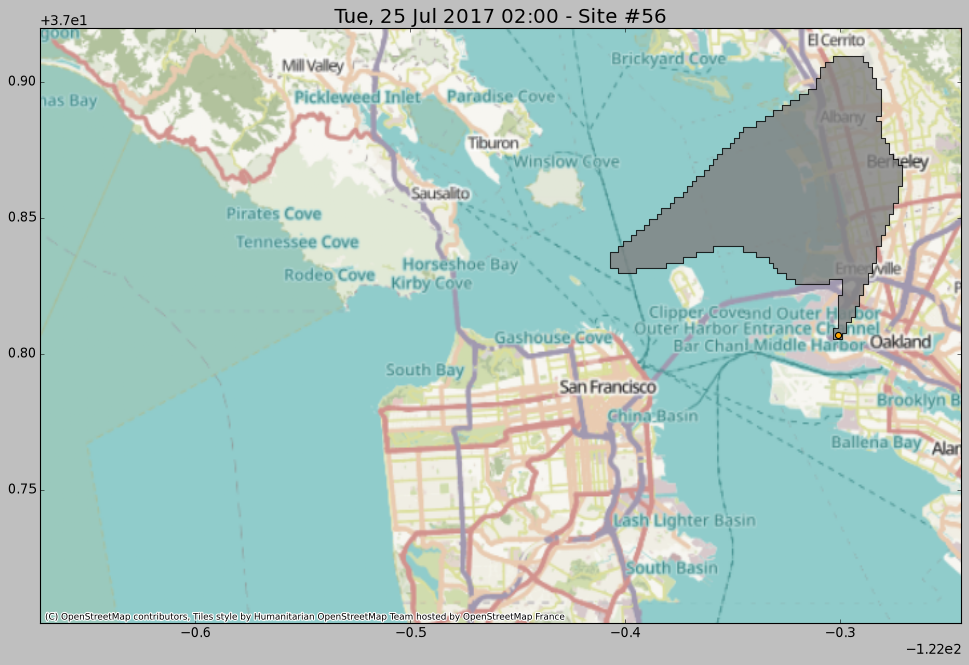

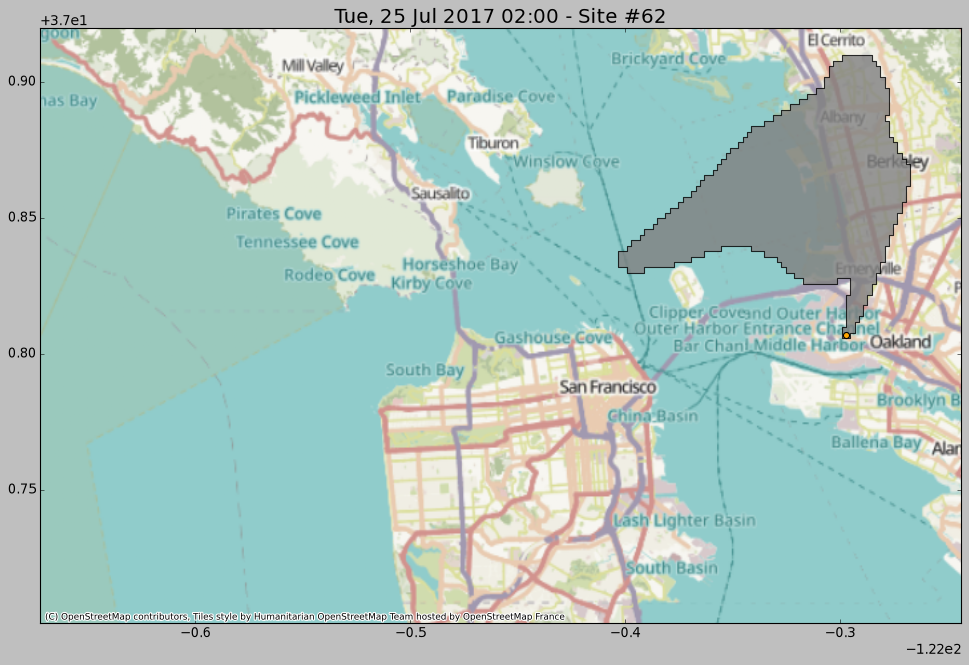

In [55]:
import matplotlib.pyplot as plt
import contextily as cx
import geopandas as gpd

plt.style.use("classic")
for index, row in gdf.iterrows():
    fig, ax = plt.subplots(figsize=(12,10), layout='constrained')
    # Add a buffer to zoom out and include longer air tracker footprints
    minx, miny, maxx, maxy = gdf.total_bounds
    buffer_x = (maxx - minx) * 0.05
    buffer_y = (maxy - miny) * 0.05
    ax.set_xlim(minx - buffer_x, maxx + buffer_x)
    ax.set_ylim(miny - buffer_y, maxy + buffer_y)
    # Plot the Air Tracker footprint originating from the sensor at that time
    gdf.loc[[index]].plot(alpha=0.8, ax=ax, color="gray")
    # Plot the sensor's location on the map using the 'Latitude' and 'Longitude' columns
    sensor_loc = gpd.GeoDataFrame(gdf.loc[[index]],
                                  geometry=gpd.points_from_xy(row[['Longitude']], row[['Latitude']]),
                                  crs=gdf.crs)
    sensor_loc.plot(ax=ax, color='orange', edgecolor='black', markersize = 30)
    # Set each plot's title to show the date and site identifier
    ax.set_title(f'{row['Datetime'].strftime('%a, %d %b %Y %H:%M')} - Site #{row['Site']}', size = 18)
    # Add basemap
    cx.add_basemap(ax=ax, crs=gdf.crs)

    plt.show()